# 03 — TS2Vec embeddings + anomaly scoring (v2 — memory-safe)**Goal:** train TS2Vec, extract one embedding per trip, score anomalies with Isolation Forest, and compare head-to-head against the baseline.**Before running:**1. Switch runtime to **T4 GPU** (Runtime → Change runtime type → T4 GPU).2. **Runtime → Restart runtime** to clear any leftover memory from previous attempts.**Strategy this time:**- Train on a **random 10k subset** for **5 epochs** (instead of 200 iterations on the full 54k) → gives a real loss curve and a properly trained model in ~5 minutes.- **Encode all 54k trips in chunks** of 256, pooling on the fly, so peak memory stays small.- **Free intermediate variables** after each step.- **Checkpoint the trained model** to Drive so reruns can skip training.---## 1. Setup

In [19]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Verify GPU is on
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError("Switch the runtime to T4 GPU before continuing.")

CUDA available: True
Device: Tesla T4
GPU memory: 15.6 GB


In [21]:
# Clone TS2Vec
import os, sys, gc

if not os.path.exists("/content/ts2vec"):
    !git clone -q https://github.com/zhihanyue/ts2vec.git /content/ts2vec
if "/content/ts2vec" not in sys.path:
    sys.path.insert(0, "/content/ts2vec")

from ts2vec import TS2Vec
print("TS2Vec ready.")

TS2Vec ready.


---## 2. Load only what we need from the eval bundleSkip `features` (we don't need them in this notebook) to save ~3 MB and keep things lean.

In [22]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/ADM_project"
EVAL_PATH   = os.path.join(PROJECT_DIR, "eval_data.pkl")
MODEL_PATH  = os.path.join(PROJECT_DIR, "ts2vec_model.pkl")
TS2VEC_OUT  = os.path.join(PROJECT_DIR, "ts2vec_results.pkl")

with open(EVAL_PATH, "rb") as f:
    eval_bundle = pickle.load(f)

trajectories     = eval_bundle["trajectories"]
labels           = eval_bundle["labels"]
label_types      = eval_bundle["label_types"]
baseline_scores  = eval_bundle["baseline_scores"]
baseline_metrics = eval_bundle["baseline_metrics"]
SEED             = eval_bundle["seed"]
del eval_bundle  # free the rest (features, etc. — not needed here)
gc.collect()

rng = np.random.default_rng(SEED)
N   = len(trajectories)
print(f"Loaded {N} trips, {labels.sum()} anomalies")
print(f"Baseline global ROC-AUC: {baseline_metrics['global']['roc_auc']:.3f}")

Loaded 54573 trips, 800 anomalies
Baseline global ROC-AUC: 0.809


---## 3. Preprocess to 3-channel time series (deltas + speed)Convert each trip from `(N, 2)` to `(N−1, 3)` channels: dlon in meters, dlat in meters, speed in m/s.

In [23]:
LAT_TO_M = 111_000
LON_TO_M = 111_000 * np.cos(np.deg2rad(41.16))
MAX_LEN  = 200

def trip_to_channels(pts):
    pts = np.asarray(pts, dtype=np.float64)
    diffs = np.diff(pts, axis=0)
    dx = diffs[:, 0] * LON_TO_M
    dy = diffs[:, 1] * LAT_TO_M
    speed = np.sqrt(dx * dx + dy * dy) / 15.0
    return np.stack([dx, dy, speed], axis=-1).astype(np.float32)

channels = [trip_to_channels(p) for p in trajectories]
real_lengths = np.array([c.shape[0] for c in channels])

# Free trajectories — we won't need the raw (lon, lat) anymore in this notebook
del trajectories
gc.collect()

print(f"Converted {len(channels)} trips. Seq length: median {int(np.median(real_lengths))}, max {real_lengths.max()}")

Converted 54573 trips. Seq length: median 42, max 359


In [24]:
# Pad / truncate to (N, MAX_LEN, 3) with NaN
data_arr = np.full((N, MAX_LEN, 3), np.nan, dtype=np.float32)
for i, c in enumerate(channels):
    L = min(len(c), MAX_LEN)
    data_arr[i, :L] = c[:L]

# Free the list of arrays — we have everything in data_arr now
del channels
gc.collect()

print(f"Padded shape: {data_arr.shape}  (~{data_arr.nbytes / 1024**2:.1f} MB)")

Padded shape: (54573, 200, 3)  (~124.9 MB)


In [25]:
# Standardize each channel using stats from non-NaN positions
flat = data_arr.reshape(-1, 3)
ch_mean = np.nanmean(flat, axis=0)
ch_std  = np.nanstd(flat, axis=0) + 1e-9
print(f"Channel means: {ch_mean.round(2)}")
print(f"Channel stds:  {ch_std.round(2)}")

data_norm = (data_arr - ch_mean) / ch_std
del data_arr  # only keep the normalized version
gc.collect()

print(f"Normalized shape: {data_norm.shape}")

Channel means: [-5.07 12.93  7.79]
Channel stds:  [525.98 223.76  37.28]
Normalized shape: (54573, 200, 3)


---## 4. Train TS2Vec on a 10k subset for 5 epochsThis gives us a proper loss curve AND a properly trained model. Training on a subset is fine for self-supervised learning — what matters is *variety* of samples, not raw volume.The trained model is saved to Drive (`ts2vec_model.pkl`). If you rerun this notebook later, the next cell will detect the saved model and skip retraining.

In [26]:
TRAIN_SIZE = 10_000
N_EPOCHS   = 5

# Pick a random subset for training
train_idx = rng.choice(N, size=TRAIN_SIZE, replace=False)
train_data = data_norm[train_idx]
print(f"Training subset: {train_data.shape}")

Training subset: (10000, 200, 3)


In [27]:
# Build TS2Vec model
model = TS2Vec(
    input_dims=3,
    output_dims=320,
    hidden_dims=64,
    depth=10,
    device="cuda",
    lr=0.001,
    batch_size=16,
)

# Train — pass n_epochs (NOT n_iters) so we get loss logged per epoch
print(f"Training TS2Vec for {N_EPOCHS} epochs on {TRAIN_SIZE} trips...")
print("(expect ~5–10 minutes on T4)")
loss_log = model.fit(train_data, n_epochs=N_EPOCHS, verbose=True)
print(f"Done. Loss log has {len(loss_log)} entries: {[round(l, 4) for l in loss_log]}")

# Free training subset
del train_data
gc.collect()
torch.cuda.empty_cache()

Training TS2Vec for 5 epochs on 10000 trips...
(expect ~5–10 minutes on T4)
Epoch #0: loss=1.9393359383583069
Epoch #1: loss=1.4305431404113769
Epoch #2: loss=1.2421819593906402
Epoch #3: loss=1.102322163105011
Epoch #4: loss=1.099492329788208
Done. Loss log has 5 entries: [1.9393, 1.4305, 1.2422, 1.1023, 1.0995]


In [28]:
# Save the trained model to Drive so reruns can skip training
import torch as _torch
_torch.save(model.net.state_dict(), MODEL_PATH.replace('.pkl', '.pt'))
with open(MODEL_PATH, "wb") as f:
    pickle.dump({
        "loss_log":     loss_log,
        "train_idx":    train_idx,
        "ch_mean":      ch_mean,
        "ch_std":       ch_std,
        "train_size":   TRAIN_SIZE,
        "n_epochs":     N_EPOCHS,
    }, f)
print(f"Saved checkpoint metadata to {MODEL_PATH}")
print(f"Saved weights to {MODEL_PATH.replace('.pkl', '.pt')}")

Saved checkpoint metadata to /content/drive/MyDrive/ADM_project/ts2vec_model.pkl
Saved weights to /content/drive/MyDrive/ADM_project/ts2vec_model.pt


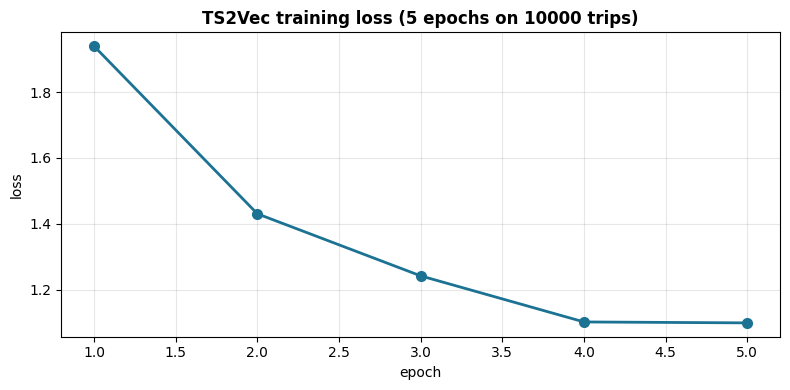

In [29]:
# Plot the training loss curve — should now actually show something
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_log) + 1), loss_log, color="#1C7293",
         marker="o", linewidth=2, markersize=7)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"TS2Vec training loss ({N_EPOCHS} epochs on {TRAIN_SIZE} trips)",
          fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_ts2vec_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

The curve should show loss decreasing across epochs — a sign that TS2Vec is learning meaningful representations. If the curve is flat, training failed (rare). If it's still descending sharply at the end, you could bump `N_EPOCHS` up to 7–10.---## 5. Encode ALL 54k trips in chunks (memory-safe)The previous version of this cell tried to encode everything at once and crashed Colab with a 14 GB tensor. This version processes 256 trips at a time and pools to a fixed-size embedding immediately, so peak extra memory is ~60 MB per chunk.

In [30]:
from tqdm import tqdm

CHUNK = 256
embeddings = np.zeros((N, 320), dtype=np.float32)

print(f"Encoding {N} trips in chunks of {CHUNK}...")
for start in tqdm(range(0, N, CHUNK)):
    end = min(start + CHUNK, N)
    # Encode just this chunk — shape: (chunk_size, MAX_LEN, 320)
    repr_chunk = model.encode(data_norm[start:end], batch_size=32)
    # Mean-pool over the valid (non-padded) timesteps
    for i, j in enumerate(range(start, end)):
        L = min(real_lengths[j], MAX_LEN)
        embeddings[j] = repr_chunk[i, :L].mean(axis=0)
    del repr_chunk
    gc.collect()
    torch.cuda.empty_cache()

print(f"Done. Embeddings shape: {embeddings.shape}  ({embeddings.nbytes / 1024**2:.1f} MB)")

Encoding 54573 trips in chunks of 256...


100%|██████████| 214/214 [01:12<00:00,  2.95it/s]

Done. Embeddings shape: (54573, 320)  (66.6 MB)


In [31]:
# We don't need data_norm anymore — free it
del data_norm
gc.collect()
torch.cuda.empty_cache()
print("Freed data_norm.")

Freed data_norm.


---## 6. Score anomalies with Isolation ForestSame exact settings as the baseline (200 trees, contamination='auto', same seed) — only the input changes: 320-dim TS2Vec embeddings instead of 8 hand-crafted features.

In [32]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)

clf = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)
clf.fit(emb_scaled)
ts2vec_scores = -clf.score_samples(emb_scaled)

print(f"Computed {len(ts2vec_scores)} anomaly scores")
print(f"Score range: [{ts2vec_scores.min():.3f}, {ts2vec_scores.max():.3f}]")

Computed 54573 anomaly scores
Score range: [0.394, 0.715]


---## 7. Evaluate — head-to-head with baseline

In [33]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(scores, labels, label_types):
    out = {"global": {
        "roc_auc": roc_auc_score(labels, scores),
        "pr_auc":  average_precision_score(labels, scores),
    }, "per_type": {}}
    for t in ["detour", "gps_jump", "noise", "reversal"]:
        mask = (label_types == "normal") | (label_types == t)
        out["per_type"][t] = {
            "roc_auc": roc_auc_score(labels[mask], scores[mask]),
            "pr_auc":  average_precision_score(labels[mask], scores[mask]),
        }
    return out

# Recompute BOTH so they use consistent keys
baseline_metrics = evaluate(baseline_scores, labels, label_types)
ts2vec_metrics   = evaluate(ts2vec_scores,   labels, label_types)

print(f"{'Metric':<28} {'Baseline':>10} {'TS2Vec':>10} {'Δ':>10}")
print("-" * 60)
b, t = baseline_metrics, ts2vec_metrics

gb, gt = b['global']['roc_auc'], t['global']['roc_auc']
print(f"{'Global ROC-AUC':<28} {gb:>10.3f} {gt:>10.3f} {gt-gb:>+10.3f}")
gb, gt = b['global']['pr_auc'], t['global']['pr_auc']
print(f"{'Global PR-AUC':<28} {gb:>10.3f} {gt:>10.3f} {gt-gb:>+10.3f}")
print()
for anom in ["detour", "gps_jump", "noise", "reversal"]:
    gb, gt = b['per_type'][anom]['roc_auc'], t['per_type'][anom]['roc_auc']
    print(f"{'  '+anom+' ROC-AUC':<28} {gb:>10.3f} {gt:>10.3f} {gt-gb:>+10.3f}")
    gb, gt = b['per_type'][anom]['pr_auc'], t['per_type'][anom]['pr_auc']
    print(f"{'  '+anom+' PR-AUC':<28} {gb:>10.3f} {gt:>10.3f} {gt-gb:>+10.3f}")

Metric                         Baseline     TS2Vec          Δ
------------------------------------------------------------
Global ROC-AUC                    0.809      0.650     -0.159
Global PR-AUC                     0.086      0.116     +0.029

  detour ROC-AUC                  0.819      0.368     -0.450
  detour PR-AUC                   0.010      0.003     -0.007
  gps_jump ROC-AUC                0.970      0.706     -0.264
  gps_jump PR-AUC                 0.125      0.116     -0.008
  noise ROC-AUC                   0.934      0.990     +0.057
  noise PR-AUC                    0.026      0.154     +0.128
  reversal ROC-AUC                0.512      0.535     +0.023
  reversal PR-AUC                 0.004      0.005     +0.000


---## 8. Comparison figures for the slides

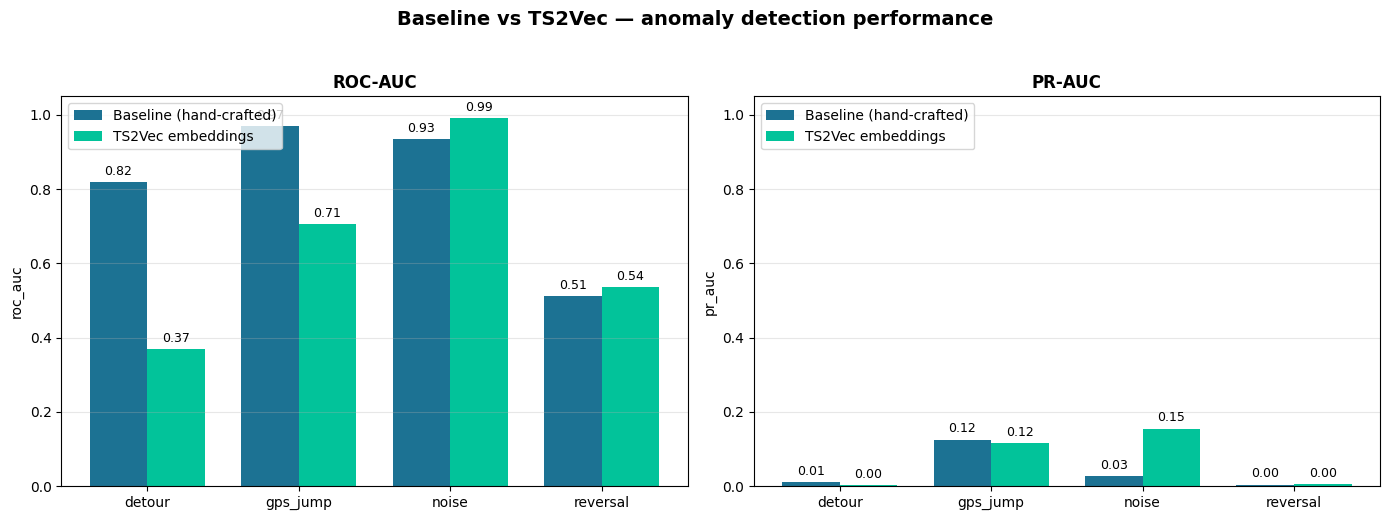

In [34]:
# Bar chart — baseline vs TS2Vec per anomaly type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
types = ["detour", "gps_jump", "noise", "reversal"]
x = np.arange(len(types))
width = 0.38

for ax, metric, title in zip(axes, ["roc_auc", "pr_auc"], ["ROC-AUC", "PR-AUC"]):
    bv = [baseline_metrics["per_type"][t][metric] for t in types]
    tv = [ts2vec_metrics["per_type"][t][metric]   for t in types]
    ax.bar(x - width/2, bv, width, label="Baseline (hand-crafted)", color="#1C7293")
    ax.bar(x + width/2, tv, width, label="TS2Vec embeddings",       color="#02C39A")
    ax.set_xticks(x); ax.set_xticklabels(types)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper left")
    ax.grid(axis="y", alpha=0.3)
    for i, (a, b_) in enumerate(zip(bv, tv)):
        ax.text(i - width/2, a + 0.02, f"{a:.2f}", ha="center", fontsize=9)
        ax.text(i + width/2, b_ + 0.02, f"{b_:.2f}", ha="center", fontsize=9)

plt.suptitle("Baseline vs TS2Vec — anomaly detection performance",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

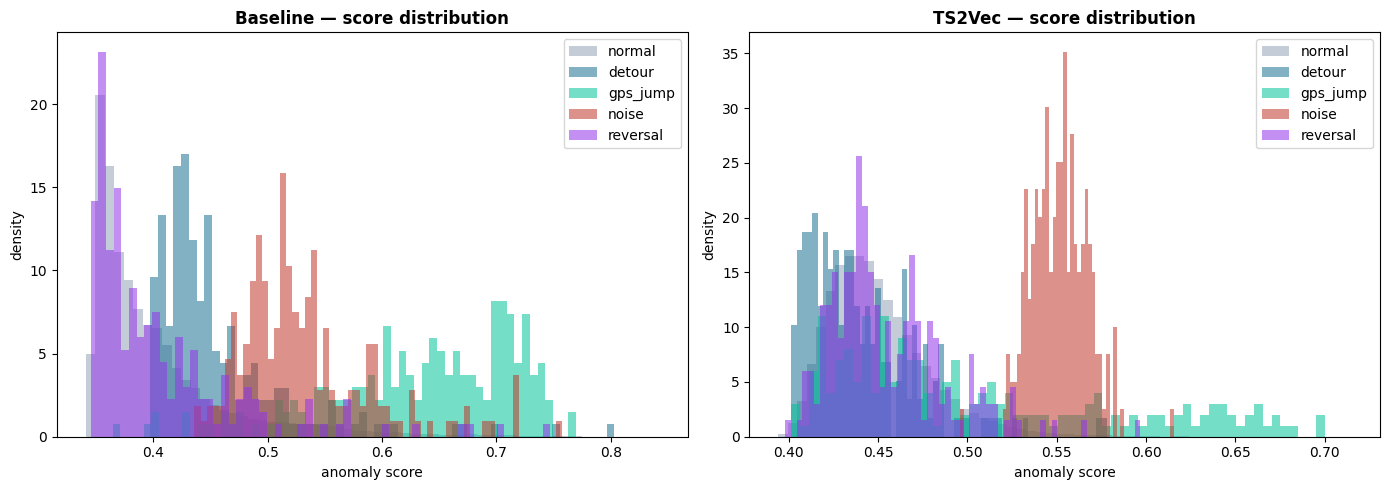

In [35]:
# Score-distribution side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
type_colors = {"normal": "#94a3b8", "detour": "#1C7293",
               "gps_jump": "#02C39A", "noise": "#c0392b", "reversal": "#9333ea"}

for ax, (scores, title) in zip(axes, [(baseline_scores, "Baseline"),
                                       (ts2vec_scores, "TS2Vec")]):
    for t in ["normal", "detour", "gps_jump", "noise", "reversal"]:
        mask = label_types == t
        ax.hist(scores[mask], bins=60, alpha=0.55, label=t,
                color=type_colors[t], density=True)
    ax.set_xlabel("anomaly score")
    ax.set_ylabel("density")
    ax.set_title(f"{title} — score distribution", fontweight="bold")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_scores_side_by_side.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---## 9. Save results for notebook 4

In [36]:
results = {
    "embeddings":       embeddings,
    "ts2vec_scores":    ts2vec_scores,
    "ts2vec_metrics":   ts2vec_metrics,
    "baseline_scores":  baseline_scores,
    "baseline_metrics": baseline_metrics,
    "labels":           labels,
    "label_types":      label_types,
    "real_lengths":     real_lengths,
    "max_len":          MAX_LEN,
    "loss_log":         loss_log,
    "train_subset_size": TRAIN_SIZE,
    "train_epochs":     N_EPOCHS,
}

with open(TS2VEC_OUT, "wb") as f:
    pickle.dump(results, f)

size_mb = os.path.getsize(TS2VEC_OUT) / 1024 / 1024
print(f"Saved to {TS2VEC_OUT} ({size_mb:.1f} MB)")
print(f"  TS2Vec global ROC-AUC: {results['ts2vec_metrics']['global']['roc_auc']:.3f}")
print(f"  baseline global ROC-AUC: {results['baseline_metrics']['global']['roc_auc']:.3f}")

Saved to /content/drive/MyDrive/ADM_project/ts2vec_results.pkl (68.4 MB)
  TS2Vec global ROC-AUC: 0.650
  baseline global ROC-AUC: 0.809


---## Done.**For the report, write down:**- TS2Vec global and per-type ROC-AUC and PR-AUC- Whether TS2Vec beat the baseline on each row (sign of Δ)- Training setup: 10k subset, 5 epochs, on T4 GPU- Note in the methodology: training a self-supervised model on a 10k random subset is a standard choice — what matters for SSL is diversity, not volume; we then encoded all 54k trips with the trained model.**Figures saved (download for the slides):**- `fig_ts2vec_loss.png` — training loss across epochs- `fig_comparison.png` — headline bar chart- `fig_scores_side_by_side.png` — score distributions**Sanity checks:**- Loss curve goes down across the 5 epochs- Embeddings shape `(54573, 320)`- Per-type AUCs are reasonable (not all 0.5, not all 1.0)- The comparison table has finite values everywhere**Next:** `04_maps_and_analysis.ipynb` — plot top-scored real anomalies on a Porto map (qualitative analysis), inspect cases where TS2Vec disagrees with the baseline, finalize numbers for the report. That's where the "insight into data analysis" 5 points come from.